# Elastic Net e ajuste de alpha

**Tema:** Aprendizado Supervisionado › Regularização

Este notebook mostra o cenário onde Elastic Net supera Ridge e Lasso
isoladamente — muitas features correlacionadas em grupos, com esparsidade
real entre os grupos — e fecha com o fluxo correto de ajuste de
hiperparâmetro por validação cruzada, sem vazar o conjunto de teste.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(15)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um cenário desenhado para o Elastic Net: grupos correlacionados + esparsidade

3 grupos de 4 features cada (features dentro do grupo são quase idênticas
entre si); só 2 dos 3 grupos têm efeito real no alvo.

In [2]:
n = 400


def gera_grupo_correlacionado(n, tamanho, rng):
    fator_comum = rng.normal(0, 1, n)
    return np.column_stack([fator_comum + rng.normal(0, 0.15, n) for _ in range(tamanho)])


grupo_1 = gera_grupo_correlacionado(n, 4, rng)  # tem efeito real
grupo_2 = gera_grupo_correlacionado(n, 4, rng)  # tem efeito real
grupo_3 = gera_grupo_correlacionado(n, 4, rng)  # SEM efeito real (ruído)

X = np.column_stack([grupo_1, grupo_2, grupo_3])
X = StandardScaler().fit_transform(X)

# efeito real: soma dos fatores comuns dos grupos 1 e 2, nada do grupo 3
beta_real = np.array([1.5] * 4 + [1.0] * 4 + [0.0] * 4)
y = X @ beta_real + rng.normal(0, 1, n)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)
print(f"shape: {X.shape}  (3 grupos de 4 features colineares cada)")

shape: (400, 12)  (3 grupos de 4 features colineares cada)


## 2. Comparando Ridge, Lasso e Elastic Net numa penalidade fixa e moderada

Para ver a diferença de COMPORTAMENTO entre os três, fixamos o mesmo
`alpha` nos três primeiro (a escolha por validação cruzada vem na seção 4,
separadamente — CV aqui tenderia a escolher uma penalidade fraca demais
para tornar a diferença visível, porque $n=400$ já é generoso para 12
features).

In [3]:
ALPHA_ILUSTRATIVO = 0.2

modelos = {
    "Ridge": Ridge(alpha=ALPHA_ILUSTRATIVO),
    "Lasso": Lasso(alpha=ALPHA_ILUSTRATIVO, max_iter=5000),
    "Elastic Net (l1_ratio=0.5)": ElasticNet(
        alpha=ALPHA_ILUSTRATIVO, l1_ratio=0.5, max_iter=5000),
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)
    rmse = np.sqrt(mean_squared_error(y_teste, pred))
    resultados[nome] = (modelo.coef_, rmse)
    print(f"{nome:<28s} RMSE={rmse:.4f}   "
          f"nº coeficientes zerados={np.sum(np.abs(modelo.coef_) < 1e-6)}/12")

Ridge                        RMSE=1.0852   nº coeficientes zerados=0/12
Lasso                        RMSE=1.1203   nº coeficientes zerados=4/12
Elastic Net (l1_ratio=0.5)   RMSE=1.1136   nº coeficientes zerados=1/12


## 3. Visualizando os coeficientes por grupo

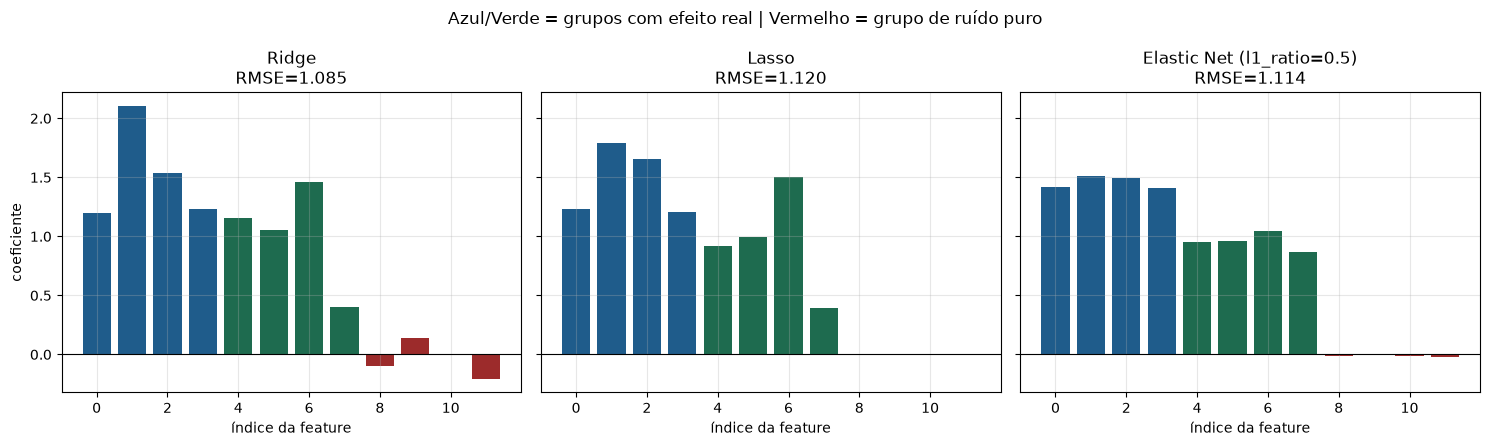

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
cores_grupo = [AZUL] * 4 + [VERDE] * 4 + [VERMELHO] * 4
for ax, (nome, (coef, rmse)) in zip(axes, resultados.items()):
    ax.bar(range(12), coef, color=cores_grupo)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{nome}\nRMSE={rmse:.3f}")
    ax.set_xlabel("índice da feature")
axes[0].set_ylabel("coeficiente")
fig.suptitle("Azul/Verde = grupos com efeito real | Vermelho = grupo de ruído puro")
plt.tight_layout(); plt.show()

**Leitura esperada:** nesta penalidade, o Lasso já identifica corretamente
o **grupo 3 inteiro** (ruído, sem efeito real) e zera as 4 features dele —
mas mantém quase todas as features dos grupos 1 e 2, porque o sinal real
ali é forte o bastante para "sobreviver" a essa penalidade. Ridge encolhe
tudo suavemente e mantém as 12 features com peso não-zero, incluindo as do
grupo 3 — nenhuma é eliminada, mesmo sendo puro ruído. Se você aumentar
`ALPHA_ILUSTRATIVO` (tente 0,3 ou mais), vai ver o comportamento mais
conhecido do Lasso aparecer: ele passa a "escolher" arbitrariamente só
algumas features dentro dos próprios grupos 1 e 2 também, uma vez que a
penalidade fica forte o suficiente para competir com o sinal real — a razão
pela qual, sob colinearidade forte, Elastic Net costuma generalizar melhor
que Lasso puro: ele distribui peso de forma mais equilibrada dentro de cada
grupo correlacionado, em vez de depender de uma escolha só.

## 4. O fluxo correto de ajuste de hiperparâmetro

`RidgeCV`, `LassoCV` e `ElasticNetCV` já fazem validação cruzada
internamente para escolher alpha — o alpha escolhido nunca "viu" o
`X_teste`. Vamos confirmar isso explicitamente.

In [5]:
modelo_en = ElasticNetCV(alphas=np.logspace(-3, 1, 50), l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                         max_iter=5000, random_state=0, cv=5)
modelo_en.fit(X_treino, y_treino)

print(f"alpha escolhido por CV (só no treino): {modelo_en.alpha_:.5f}")
print(f"l1_ratio escolhido por CV (só no treino): {modelo_en.l1_ratio_}")
print(f"\nRMSE no teste (NUNCA usado para escolher hiperparâmetros): "
      f"{np.sqrt(mean_squared_error(y_teste, modelo_en.predict(X_teste))):.4f}")

alpha escolhido por CV (só no treino): 0.03556
l1_ratio escolhido por CV (só no treino): 0.1

RMSE no teste (NUNCA usado para escolher hiperparâmetros): 1.0820


> **Por que isso importa:** se o alpha fosse escolhido testando vários
> valores diretamente contra `X_teste` e ficando com o melhor, o número
> final de desempenho estaria inflado — o teste teria influenciado a
> escolha do modelo, mesmo sem "treinar" nele diretamente. É a mesma lógica
> de vazamento do tema 3: qualquer decisão informada pelos dados precisa
> respeitar a fronteira treino/teste, incluindo escolha de hiperparâmetro.

## O que levar deste notebook

- Elastic Net combina a esparsidade do Lasso com a estabilidade do Ridge
  sob features fortemente correlacionadas — o cenário onde nenhum dos dois
  sozinho é ideal.
- `RidgeCV`, `LassoCV` e `ElasticNetCV` escolhem o hiperparâmetro certo por
  validação cruzada interna, nunca tocando o conjunto de teste.
- Comparar os coeficientes lado a lado, não só o RMSE final, revela COMO
  cada método chegou ao resultado — informação valiosa para decidir qual
  usar em um problema novo.

→ Próximo: o notebook de **exercícios** do módulo.